# Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Important Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.base import BaseEstimator, RegressorMixin
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import os

# Sentinel-2

## Data Loading

In [ ]:
save_dir = "/content/drive/MyDrive/Thesis/Trained_models/"
file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_with_veg_data.csv"

print("Loading data...")
df = pd.read_csv(file_path)
print("Data is loaded")

print("\nData preparation...")

df1 = df.loc[df["age"] != 5].dropna()

df1.drop(columns=["age", "basal_area", "height", "poly_id", "S2_Date"], axis=1, inplace=True)

y = df1["stock_per_ha"]
X = df1.drop(columns="stock_per_ha", axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f"\nDatasets are read! X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! X_train shape: (284286, 52), X_test shape: (50169, 52), X_val shape: (59022, 52)


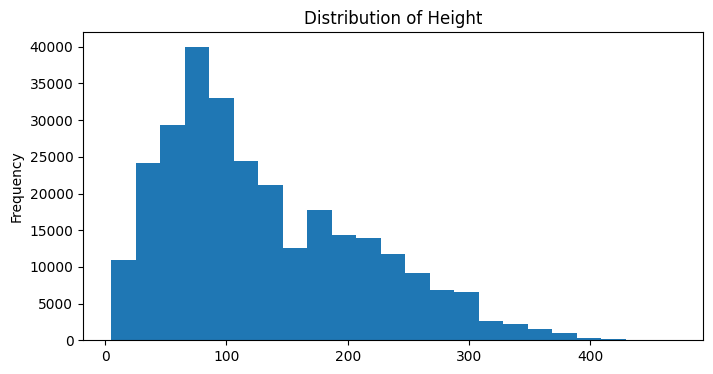

In [ ]:
plt.figure(figsize=(8, 4))
y_train.plot.hist(bins = 23)
plt.title("Distribution of Height")
plt.show()

### Cleaning RAM

In [ ]:
import gc
del df, df1, X, y

gc.collect()

4290

## RandomizedSearch

### Decoupled RandomizedSearch

In [ ]:
estimator_reg = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    device="cuda"
)

param_dist_reg = {
    'n_estimators': [200, 500, 1000, 2000],
    'max_depth': [5, 7, 9, 11, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'gamma': [0, 0.1, 0.5, 1.0]
}

search_reg = RandomizedSearchCV(
    estimator=estimator_reg,
    param_distributions=param_dist_reg,
    n_iter=200, # 100 tests for the regressor
    scoring='neg_mean_squared_error', # Standard for regression tuning
    n_jobs=2,
    cv=5,
    verbose=1,
    random_state=42
)

search_reg.fit(X_train, y_train)
best_reg_params = search_reg.best_params_
print("Best Regressor Params:", best_reg_params)


Fitting 5 folds for each of 200 candidates, totalling 1000 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Regressor Params: {'subsample': 0.7, 'n_estimators': 2000, 'min_child_weight': 7, 'max_depth': 15, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.7}


**Best Params**

In [ ]:
# Best Regressor Params: {'subsample': 0.7, 'n_estimators': 2000, 'min_child_weight': 7, 'max_depth': 15, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.7}

# Alpha Earth Foundation + Sentinel-2



## Data Loading

In [ ]:
save_dir = "/content/drive/MyDrive/Thesis/Trained_models/"
file_path = "/content/drive/MyDrive/Thesis/Train_data/s2_aef_with_veg_data.csv"

print("Loading data...")
df = pd.read_csv(file_path)
print("Data is loaded")

print("\nData preparation...")

df1 = df.loc[df["age"] != 5].dropna()

df1.drop(columns=["age", "basal_area", "height", "poly_id", "S2_Date"], axis=1, inplace=True)

y = df1["stock_per_ha"]
X = df1.drop(columns="stock_per_ha", axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f"\nDatasets are read! X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")

Loading data...
Data is loaded

Data preparation...

Datasets are read! X_train shape: (284117, 308), X_test shape: (50139, 308), X_val shape: (58987, 308)


In [ ]:
import gc
del df, df1, X, y

gc.collect()

0

## RandomizedSearch

### Decoupled RandomizedSearch

In [ ]:
estimator_reg = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    tree_method='hist',
    device="cuda"
)

param_dist_reg = {
    'n_estimators': [200, 500, 1000, 2000],
    'max_depth': [5, 7, 9, 11, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'gamma': [0, 0.1, 0.5, 1.0]
}

search_reg = RandomizedSearchCV(
    estimator=estimator_reg,
    param_distributions=param_dist_reg,
    n_iter=200, # 200 tests for the regressor
    scoring='neg_mean_squared_error', # Standard for regression tuning
    n_jobs=5,
    cv=5,
    verbose=1,
    random_state=42
)

search_reg.fit(X_train, y_train)
best_reg_params = search_reg.best_params_
print("Best Regressor Params:", best_reg_params)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Regressor Params: {'subsample': 0.9, 'n_estimators': 2000, 'min_child_weight': 7, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.9}


**Best Params**

In [ ]:
# Best Regressor Params: {'subsample': 0.9, 'n_estimators': 2000, 'min_child_weight': 7, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.9}